# ⚽ 축구 데이터 분석 입문: StatsBomb 오픈 데이터 기초

이 노트북에서는 **StatsBomb Open Data**를 사용하여 실제 축구 경기 이벤트 데이터를 불러오고 분석하는 방법을 알아봅니다.

### 다루는 내용:
1. 사용 가능한 대회(Competitions) 및 시즌 조회
2. 특정 대회의 경기(Matches) 목록 탐색
3. 경기 라인업(Lineups) 및 이벤트(Events) 데이터 로드
4. 슛(Shot), 패스(Pass) 이벤트 필터링 및 xG 기초 분석

In [1]:
# 필요한 라이브러리 임포트
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsbombpy import sb
from mplsoccer import Pitch

# 판다스 출력 옵션
pd.set_option('display.max_columns', 30)

## 1. 사용 가능한 대회 목록 확인
StatsBomb에서 무료로 제공하는 오픈 데이터 대회 목록을 확인합니다.

In [2]:
comps = sb.competitions()
comps[['competition_id', 'season_id', 'country_name', 'competition_name', 'season_name', 'match_available']].head(15)

,competition_id,season_id,country_name,competition_name,season_name,match_available
0,9,281,Germany,1. Bundesliga,2023/2024,2024-09-28T20:46:38.893391
1,9,27,Germany,1. Bundesliga,2015/2016,2024-05-19T11:11:14.192381
2,1267,107,Africa,African Cup of Nations,2023,2026-05-12T21:18:08.827431
3,16,4,Europe,Champions League,2018/2019,2026-05-15T15:54:04.598614
4,16,1,Europe,Champions League,2017/2018,2024-02-13T02:35:28.134882
5,16,2,Europe,Champions League,2016/2017,2024-02-13T02:37:32.205154
6,16,27,Europe,Champions League,2015/2016,2024-06-12T07:45:38.786894
7,16,26,Europe,Champions League,2014/2015,2024-02-12T12:49:54.914228
8,16,25,Europe,Champions League,2013/2014,2024-02-12T12:48:48.479157
9,16,24,Europe,Champions League,2012/2013,2024-02-12T12:47:34.340413


## 2. 2022 FIFA 카타르 월드컵 경기 목록 조회
- `competition_id`: 43
- `season_id`: 106

In [3]:
matches = sb.matches(competition_id=43, season_id=106)
print(f"총 경기 수: {len(matches)}")
matches[['match_id', 'match_date', 'home_team', 'home_score', 'away_score', 'away_team', 'competition_stage']].head(10)

총 경기 수: 64


,match_id,match_date,home_team,home_score,away_score,away_team,competition_stage
0,3857276,2022-12-01,Canada,1,2,Morocco,Group Stage
1,3857271,2022-11-21,England,6,2,Iran,Group Stage
2,3857296,2022-12-01,Croatia,0,0,Belgium,Group Stage
3,3857274,2022-11-25,Netherlands,1,1,Ecuador,Group Stage
4,3857255,2022-12-01,Japan,2,1,Spain,Group Stage
5,3857272,2022-11-25,England,0,0,United States,Group Stage
6,3857278,2022-11-29,Iran,0,1,United States,Group Stage
7,3857277,2022-11-23,Morocco,0,0,Croatia,Group Stage
8,3857273,2022-11-25,Wales,0,2,Iran,Group Stage
9,3857275,2022-11-30,Tunisia,1,0,France,Group Stage


## 3. 2022 월드컵 결승전 (아르헨티나 vs 프랑스) 데이터 가져오기

In [4]:
final_match = matches[matches['competition_stage'] == 'Final'].iloc[0]
match_id = final_match['match_id']
print(f"선택된 경기: {final_match['home_team']} {final_match['home_score']} : {final_match['away_score']} {final_match['away_team']} (Match ID: {match_id})")

선택된 경기: Argentina 3 : 3 France (Match ID: 3869685)


In [5]:
# 경기 이벤트 데이터 불러오기
events = sb.events(match_id=match_id)
print(f"총 이벤트 수: {len(events)}")
events[['minute', 'second', 'team', 'player', 'type']].head(15)

총 이벤트 수: 4407


,minute,second,team,player,type
0,0,0,Argentina,NaN,Starting XI
1,0,0,France,NaN,Starting XI
2,0,0,France,NaN,Half Start
3,0,0,Argentina,NaN,Half Start
4,45,0,France,NaN,Half Start
5,45,0,Argentina,NaN,Half Start
6,90,0,France,NaN,Half Start
7,90,0,Argentina,NaN,Half Start
8,105,0,France,NaN,Half Start
9,105,0,Argentina,NaN,Half Start


## 4. 슈팅(Shot) 및 기대 득점(xG) 분석

In [6]:
shots = events[events['type'] == 'Shot'].copy()
shots[['minute', 'team', 'player', 'shot_statsbomb_xg', 'shot_outcome', 'shot_type']].head(10)

,minute,team,player,shot_statsbomb_xg,shot_outcome,shot_type
4207,4,Argentina,Alexis Mac Allister,0.024542,Saved,Open Play
4208,7,Argentina,Rodrigo Javier De Paul,0.062813,Blocked,Open Play
4209,16,Argentina,Ángel Fabián Di María Hernández,0.106801,Off T,Open Play
4210,22,Argentina,Lionel Andrés Messi Cuccittini,0.783500,Goal,Penalty
4211,31,Argentina,Alexis Mac Allister,0.010578,Wayward,Open Play
4212,35,Argentina,Ángel Fabián Di María Hernández,0.303409,Goal,Open Play
4213,48,Argentina,Rodrigo Javier De Paul,0.040216,Saved,Open Play
4214,58,Argentina,Julián Álvarez,0.059534,Saved,Open Play
4215,59,Argentina,Lionel Andrés Messi Cuccittini,0.115560,Off T,Open Play
4216,67,France,Randal Kolo Muani,0.096184,Off T,Open Play


In [7]:
# 팀별 총 xG 합계 비교
team_xg = shots.groupby('team')['shot_statsbomb_xg'].agg(['count', 'sum']).rename(columns={'count': '총 슈팅 수', 'sum': '총 xG'})
team_xg['xG / 슈팅'] = team_xg['총 xG'] / team_xg['총 슈팅 수']
team_xg

,총 슈팅 수,총 xG,xG / 슈팅
team,,,
Argentina,24,5.892306,0.245513
France,14,5.406618,0.386187


## 5. 슈팅 위치(Shot Map) 간단 시각화

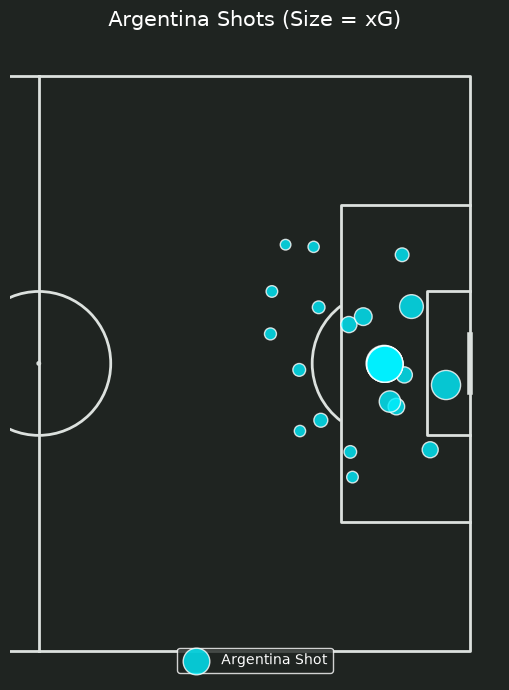

In [8]:
# 좌표 분리
shots['x'] = shots['location'].apply(lambda loc: loc[0] if isinstance(loc, list) else np.nan)
shots['y'] = shots['location'].apply(lambda loc: loc[1] if isinstance(loc, list) else np.nan)

# 피치 생성 (하프 피치)
pitch = Pitch(pitch_type='statsbomb', pitch_color='#1f2421', line_color='#dce1de', half=True)
fig, ax = pitch.draw(figsize=(10, 7))
fig.set_facecolor('#1f2421')

# 아르헨티나 슈팅
arg_shots = shots[shots['team'] == 'Argentina']
pitch.scatter(arg_shots['x'], arg_shots['y'], 
              s=arg_shots['shot_statsbomb_xg'] * 800 + 50,
              c='#00f0ff', edgecolors='white', alpha=0.8, ax=ax, label='Argentina Shot')

ax.legend(facecolor='#1f2421', edgecolor='white', labelcolor='white')
ax.set_title("Argentina Shots (Size = xG)", color='white', fontsize=15, pad=15)
plt.show()